# Instructions

(1) In mod08_sustainability_calculations, the energy usage is the product of the number of CPU cores, the number of runtime hours, and the number of kilowatts used per core. Update the function "compute_energy_kwh" to reflect this. _Hint_: You'll want to explore the data created in mod08_generate_emissions_data to learn the appropriate variable names.

(2) After you've updated (and saved) mod08_sustainability_calculations, run the cells in this notebook and answer the three discussion question. 

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from mod08_generate_emissions_data import generate_data
from mod08_sustainability_calculations import (
    compute_energy_kwh,
    compute_emissions,
    emissions_by_region,
    compute_total_runtime
)

### Get the data

In [14]:
jobs, carbon_intensity, power_per_core_kw, max_cores_per_region = generate_data()

### Inspect the Provided Data

In [15]:
print("Jobs Dataset:")
print(jobs)

print("\nCarbon Intensity by Region (kg CO2 per kWh):")
for region, intensity in carbon_intensity.items():
    print(f"{region}: {intensity}")

Jobs Dataset:
    job_id  cpu_cores  runtime_hours
0        1          1           0.50
1        2          2           1.20
2        3          4           0.75
3        4          8           2.50
4        5          2           1.00
5        6          1           0.30
6        7         16           3.00
7        8          4           1.50
8        9          8           2.00
9       10          2           0.80
10      11          4           0.50
11      12          8           2.25
12      13          2           1.60
13      14          8           0.90
14      15         16           1.10

Carbon Intensity by Region (kg CO2 per kWh):
coal_heavy_region: 0.9
renewable_region: 0.05


### Compute Energy Usage

In [16]:
jobs_with_energy = compute_energy_kwh(jobs, power_per_core_kw)

print("Jobs with Energy Computed:")
print(jobs_with_energy)

total_energy = jobs_with_energy["energy_kwh"].sum()
print(f"\nTotal Energy Consumption: {total_energy:.4f} kWh")

Jobs with Energy Computed:
    job_id  cpu_cores  runtime_hours  energy_kwh
0        1          1           0.50       0.025
1        2          2           1.20       0.120
2        3          4           0.75       0.150
3        4          8           2.50       1.000
4        5          2           1.00       0.100
5        6          1           0.30       0.015
6        7         16           3.00       2.400
7        8          4           1.50       0.300
8        9          8           2.00       0.800
9       10          2           0.80       0.080
10      11          4           0.50       0.100
11      12          8           2.25       0.900
12      13          2           1.60       0.160
13      14          8           0.90       0.360
14      15         16           1.10       0.880

Total Energy Consumption: 7.3900 kWh


### Compute Emissions for Each Region

In [17]:
region_emissions = emissions_by_region(jobs_with_energy, carbon_intensity)

print("Total Emissions by Region (kg CO2):")
for region, emissions in region_emissions.items():
    print(f"{region}: {emissions:.4f}")

Total Emissions by Region (kg CO2):
coal_heavy_region: 6.6510
renewable_region: 0.3695


### Visualize Emissions by Region

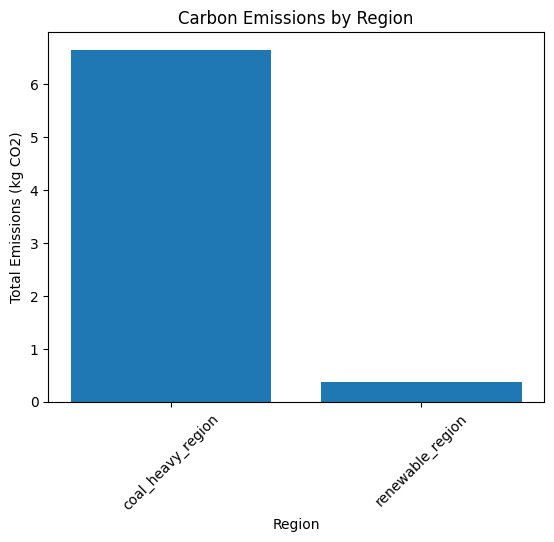

In [18]:
plt.figure()
plt.bar(region_emissions.keys(), region_emissions.values())
plt.xlabel("Region")
plt.ylabel("Total Emissions (kg CO2)")
plt.title("Carbon Emissions by Region")
plt.xticks(rotation=45)
plt.show()

### Scenario 1: All Jobs in Coal-Heavy Region

In [19]:
coal_region = max(carbon_intensity, key=carbon_intensity.get)
all_coal_emissions = compute_emissions(
    jobs_with_energy,
    carbon_intensity[coal_region]
)

all_coal_runtime = compute_total_runtime(jobs_with_energy, max_cores_per_region[coal_region])

print(f"All jobs in {coal_region}: {all_coal_emissions:.4f} kg CO2, Runtime: {all_coal_runtime:.2f} h")

All jobs in coal_heavy_region: 6.6510 kg CO2, Runtime: 7.10 h


### Scenario 2: All Jobs in Renewable Region

In [20]:
renewable_region = min(carbon_intensity, key=carbon_intensity.get)
all_renewable_emissions = compute_emissions(
    jobs_with_energy,
    carbon_intensity[renewable_region]
)

all_renewable_runtime = compute_total_runtime(jobs_with_energy, max_cores_per_region[renewable_region])

print(f"All jobs in {renewable_region}: {all_renewable_emissions:.4f} kg CO2, Runtime: {all_renewable_runtime:.2f} h")

All jobs in renewable_region: 0.3695 kg CO2, Runtime: 11.95 h


### Scenario 3: Assign High CPU Jobs to Renewable Region

In [21]:
# Decide which jobs to assign to renewable region
median = jobs_with_energy["cpu_cores"].median()

green_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] >= median]
dirty_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] < median]

# compute the new total emissions
smart_emissions = compute_emissions(green_jobs, carbon_intensity[renewable_region]) + \
                  compute_emissions(dirty_jobs, carbon_intensity[coal_region])

# compute the new total runtime (with parallelization)
smart_runtime = max(compute_total_runtime(green_jobs, max_cores_per_region[renewable_region]),
                    compute_total_runtime(dirty_jobs, max_cores_per_region[coal_region]))

print(f"High-CPU jobs to {renewable_region}: {smart_emissions:.4f} kg CO2, Runtime: {smart_runtime:.2f} h")

High-CPU jobs to renewable_region: 0.7945 kg CO2, Runtime: 10.10 h


### Strategy Comparison Plot

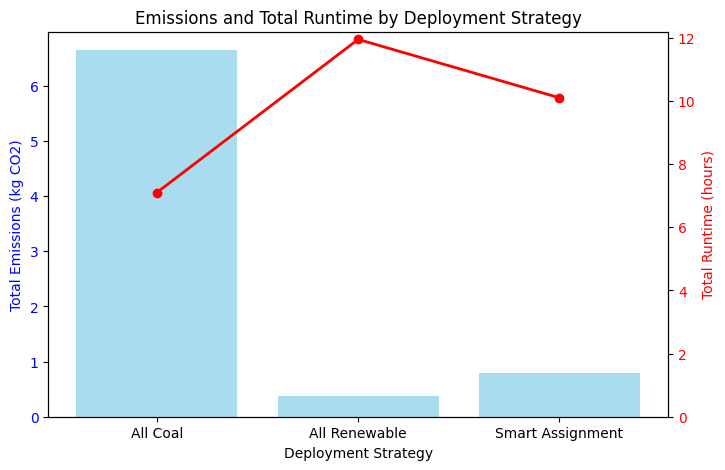

In [22]:
# Prepare data
strategy_names = ["All Coal", "All Renewable", "Smart Assignment"]
emission_values = [all_coal_emissions, all_renewable_emissions, smart_emissions]
runtime_values = [all_coal_runtime, all_renewable_runtime, smart_runtime]

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart for emissions
ax1.bar(strategy_names, emission_values, color='skyblue', alpha=0.7)
ax1.set_ylabel("Total Emissions (kg CO2)", color='blue')
ax1.set_xlabel("Deployment Strategy")
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("Emissions and Total Runtime by Deployment Strategy")

# Line chart for runtime
ax2 = ax1.twinx()
ax2.plot(strategy_names, runtime_values, color='red', marker='o', linewidth=2)
ax2.set_ylabel("Total Runtime (hours)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(bottom=0)

plt.show()

# Discussion Questions

### Similar to what we did in Scenario 3, let's look at different quantile values to decide what proportion of jobs to assign to renewable energy.

In [27]:
# Decide which jobs to assign to renewable region
cpu_threshold = jobs_with_energy["cpu_cores"].quantile(
    # enter a choice between 0 and 1 here
    0.5
    
)

green_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] >= cpu_threshold]
dirty_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] < cpu_threshold]

# compute the new total emissions
smart_emissions = compute_emissions(green_jobs, carbon_intensity[renewable_region]) + \
                  compute_emissions(dirty_jobs, carbon_intensity[coal_region])

# compute the new total runtime (with parallelization)
smart_runtime = max(compute_total_runtime(green_jobs, max_cores_per_region[renewable_region]),
                    compute_total_runtime(dirty_jobs, max_cores_per_region[coal_region]))

print(f"High-CPU jobs to {renewable_region}: {smart_emissions:.4f} kg CO2, Runtime: {smart_runtime:.2f} h")

High-CPU jobs to renewable_region: 0.7945 kg CO2, Runtime: 10.10 h


### Comment on what you believe is the most appropriate threshold given the tradeoff between emissions and runtime.

The optimal threshold depends on whether you prioritize sustainability or speed. A lower quantile minimizes emissions by shifting most work to the renewable region, but it increases runtime because that region only has 16 available cores. On the other hand a higher quantile keeps runtime low by leaving most tasks in the 32-core coal region, but it results in a higher carbon output. A 0.5 median threshold might be the most appropriate, as it is a more balanced approach.

### In this notebook, we calculate emissions and runtimes as the inputs of our cost-benefit analysis. Name and explain at least one other cost or benefit that is not considered here.

One cost not considered here would be money. The price of electricity may be more expensive in a particular region, and funding would definitely be the most important aspect considered in real life.

### List at least two different stakeholders that would be affected by a strategic decision regarding the assignment of resources explored in this notebook. In your opinion, which stakeholder's interests are most compelling?

A decision that prioritizes environmental impact would be appreciated by regulators and maybe some end users, but others may be annoyed by the longer runtimes. The most compelling interest depends on who you are asking. For the organization it would be all end users.